# FloodSentinel - Sri Lanka Flood Early Warning & Risk Prediction System
## Machine Learning Pipeline (Module Assignment)

**Module:** Machine Learning Group Assignment  
**Project Team:** Vanguard  
**Domain:** Hydro-Meteorological Disaster Risk Prediction for Sri Lanka  
**Primary Dataset:** `sri_lanka_flood_risk_dataset_25000.csv` (25,000 Records, 32 Features)  
**Target Variable:** `flood_occurrence_current_event` (Binary: Yes / No)  

---


> **Scope:** All 25,000 records are marked synthetic. Results measure current-event classification on this dataset, not verified real-world early-warning performance. The exported output is a probability and binary model flag.


## Step 1: Problem Definition 


### 1.1 Real-World Context & Disaster Landscape in Sri Lanka
Sri Lanka is an island nation heavily influenced by two major monsoon seasons:
1. **South-West Monsoon (May to September):** Brings intense precipitation to the Western, Southern, and Sabaragamuwa provinces, frequently inundating the Kelani, Kalu, Gin, and Nilwala river basins.
2. **North-East Monsoon (November to February):** Brings heavy convective rain to the Northern, Eastern, and North-Central dry zones.

Rapid urbanization, loss of natural wetlands, and inadequate drainage infrastructure have escalated flood vulnerability in dense metropolitan areas like Colombo and Gampaha, as well as downstream rural settlements. Floods inflict severe infrastructure damage, agricultural loss, and human displacement annually.

### 1.2 Objective & Machine Learning Formulation
The objective of **FloodSentinel** is to develop a robust, high-recall machine learning classification system capable of predicting active flood occurrence for any given location in Sri Lanka based on:
- **Topographic parameters** (Elevation, distance to nearest major river)
- **Meteorological indices** (7-day cumulative rainfall, monthly rainfall, natural drainage capacity)
- **Satellite Earth Observation indices** (NDVI for vegetation density, NDWI for surface water saturation)
- **Regional infrastructure & demographic metrics** (Built-up percentage, population density, road quality)

### 1.3 Mathematical Formulation & Cost-Sensitive Alert Criteria
We formulate this as a **supervised binary classification problem**:
$$\hat{y} = f(X) \in \{0, 1\}$$
where:
- $y = 0$: No flood occurrence (Normal conditions)
- $y = 1$: Active flood event (Emergency alert triggered)

#### The Asymmetric Disaster Cost Matrix:
In disaster early warning, classification errors have profoundly asymmetric consequences:
- **False Positive ($FP$):** Warning issued, but no flood occurs. Cost: Temporary evacuation inconvenience, economic friction ($C_{FP} = 1$).
- **False Negative ($FN$):** Flood occurs, but no warning is issued. Cost: Loss of human lives, destruction of property, failure of disaster response ($C_{FN} \approx 10 \times C_{FP}$).

Therefore, standard raw classification accuracy is an inappropriate metric. The primary optimization criteria are:
1. **Precision-Recall AUC (PR-AUC):** Optimal evaluation under heavy class imbalance (~9.9% positive class).
2. **Recall / Sensitivity ($\ge 90\%$):** Ensuring almost all genuine flood events trigger an alert.
3. **Cost-Sensitive Risk Score:** Producing a calibrated model probability and binary flood flag. Four operational alert tiers are outside this notebook’s implemented scope.

## Step 2: Data Collection & Ingestion 


### 2.1 Dataset Provenance & Metadata
- **File:** `assets/sri_lanka_flood_risk_dataset_25000.csv`
- **Records:** 25,000 spatial observations
- **Attributes:** 32 features encompassing geographic coordinates, elevation, rainfall measurements, satellite indices, and infrastructure attributes across all 25 Sri Lankan administrative districts.

Let us import the necessary analytical libraries and load the raw dataset.

In [139]:
# Install missing dependencies into the Python kernel selected in the IDE.
# Runs before any third-party imports; subsequent Run Alls reuse installed packages.
import importlib.util
import subprocess
import sys

required_packages = {
    'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib',
    'seaborn': 'seaborn', 'joblib': 'joblib', 'cloudpickle': 'cloudpickle',
    'sklearn': 'scikit-learn>=1.2', 'xgboost': 'xgboost',
    'lightgbm': 'lightgbm', 'catboost': 'catboost', 'optuna': 'optuna',
}
missing_packages = [package for module, package in required_packages.items()
                    if importlib.util.find_spec(module) is None]
if missing_packages:
    print(f"Installing missing packages for {sys.executable}: {missing_packages}", flush=True)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])
    importlib.invalidate_caches()
print(f"Notebook kernel: {sys.executable}")

# Import core scientific and analytical libraries
import os
import sys
import json
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import cloudpickle
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Configure visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('Libraries successfully loaded!')


Notebook kernel: c:\Users\gamit\AppData\Local\Programs\Python\Python313\python.exe
Libraries successfully loaded!


In [140]:
# Dataset Ingestion (Local Assets Path + KaggleHub Fallback)
from pathlib import Path

# Locate the project from either its root or the notebooks directory.
PROJECT_ROOT = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / 'notebooks' / 'flood_prediction_sri_lanka.ipynb').is_file()),
    Path.cwd(),
)
local_data_path = PROJECT_ROOT / 'assets' / 'sri_lanka_flood_risk_dataset_25000.csv'

if local_data_path.is_file():
    print(f"Loading local dataset from: {local_data_path}")
    df = pd.read_csv(local_data_path)
else:
    print("Local dataset not found. Attempting KaggleHub ingestion...")
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            "dewminimnaadi/sri-lanka-flood-risk-and-inundation-dataset",
            "sri_lanka_flood_risk_dataset_25000.csv"
        )
    except ImportError:
        raise FileNotFoundError(
            "Dataset file not found at 'assets/sri_lanka_flood_risk_dataset_25000.csv' "
            "and 'kagglehub' is not installed to download it."
        )

print(f"Successfully loaded dataset! Records: {df.shape[0]:,} | Features: {df.shape[1]}")


Loading local dataset from: c:\Users\gamit\OneDrive\Documents\MyWork\ML\FloodSentinel\assets\sri_lanka_flood_risk_dataset_25000.csv
Successfully loaded dataset! Records: 25,000 | Features: 32


In [141]:
# Inspect the first 5 records of the dataset
df.head()

,record_id,district,place_name,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,...,infrastructure_score,nearest_hospital_km,nearest_evac_km,flood_risk_score,flood_occurrence_current_event,inundation_area_sqm,is_good_to_live,reason_not_good_to_live,is_synthetic,generation_date
0,F100000,Kegalle,Kudagama,7.416887,81.789107,88,339.2,Wetland,Loamy,Municipal,...,12,2.76,2.74,39.56,No,0,No,Poor infrastructure,True,2025-06-02
1,F100001,Matara,Kiriwatta,6.266956,81.041369,58,1257.6,Agriculture,Clay,Municipal,...,46,1.61,8.45,30.64,No,0,Yes,NaN,True,2024-11-14
2,F100002,Trincomalee,Uduthota East,6.742164,80.927326,80,5225.3,Forest,Silty,Well,...,30,4.40,3.01,35.60,No,0,Yes,NaN,True,2024-03-01
3,F100003,Puttalam,Mahagama East,5.922365,81.484788,111,2950.4,Urban,Sandy,Surface water,...,58,11.44,4.94,17.44,No,0,Yes,NaN,True,2024-11-06
4,F100004,Matara,Welimulla East,7.899872,80.826149,26,228.3,Agriculture,Silty,Well,...,45,17.85,4.65,61.92,No,0,No,High flood risk,True,2024-07-21


### 2.2 Feature Dictionary & Attribute Schema
Below is the complete systematic classification of all 32 columns present in the raw dataset:

In [142]:
# Construct a structured schema audit dataframe
schema_audit = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null Percentage (%)': ((df.isnull().sum() / len(df)) * 100).round(2).values,
    'Sample Value': [df[col].iloc[0] for col in df.columns]
})

schema_audit

,Column Name,Data Type,Non-Null Count,Null Count,Null Percentage (%),Sample Value
0,record_id,object,25000,0,0.00,F100000
1,district,object,25000,0,0.00,Kegalle
2,place_name,object,25000,0,0.00,Kudagama
3,latitude,float64,25000,0,0.00,7.416887
4,longitude,float64,25000,0,0.00,81.789107
5,elevation_m,int64,25000,0,0.00,88
6,distance_to_river_m,float64,25000,0,0.00,339.2
7,landcover,object,25000,0,0.00,Wetland
8,soil_type,object,25000,0,0.00,Loamy
9,water_supply,object,25000,0,0.00,Municipal


### 2.3 Data Integrity & Quality Audit
Let us verify missing values, duplicate observations, and check the target class balance.

In [143]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Total Duplicate Rows: {duplicates}')

# Verify missing value columns
missing_cols = schema_audit[schema_audit['Null Count'] > 0]
print(f'Columns with Missing Values: {len(missing_cols)}')
missing_cols[['Column Name', 'Null Count', 'Null Percentage (%)', 'Sample Value']]

Total Duplicate Rows: 0
Columns with Missing Values: 2


,Column Name,Null Count,Null Percentage (%),Sample Value
10,electricity,789,3.16,Mixed
29,reason_not_good_to_live,18172,72.69,Poor infrastructure


=== TARGET VARIABLE DISTRIBUTION ===
                                Occurrences  Percentage (%)
flood_occurrence_current_event                             
No                                    22528           90.11
Yes                                    2472            9.89


C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\3333411400.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=colors)


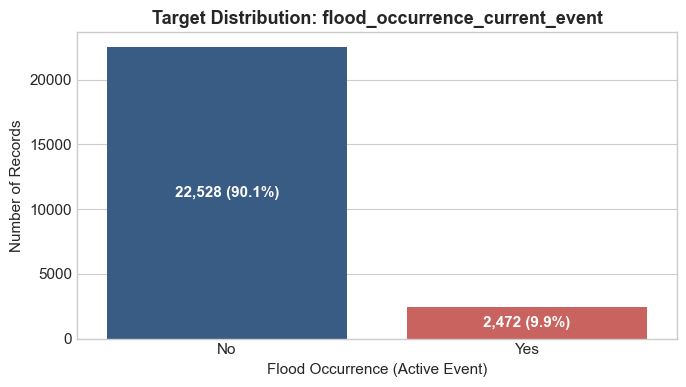

In [144]:
# Target Variable Analysis: flood_occurrence_current_event
target_counts = df['flood_occurrence_current_event'].value_counts(dropna=False)
target_pct = df['flood_occurrence_current_event'].value_counts(normalize=True, dropna=False) * 100

target_summary = pd.DataFrame({
    'Occurrences': target_counts,
    'Percentage (%)': target_pct.round(2)
})

print('=== TARGET VARIABLE DISTRIBUTION ===')
print(target_summary)

# Visual inspection of the class imbalance
plt.figure(figsize=(7, 4))
colors = ['#2b5c8f', '#d9534f']
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=colors)
plt.title('Target Distribution: flood_occurrence_current_event', fontsize=13, fontweight='bold')
plt.xlabel('Flood Occurrence (Active Event)')
plt.ylabel('Number of Records')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,} ({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

In [145]:
# Summary statistics for key physical, hydrologic, and satellite indicators
key_features = [
    'elevation_m', 'distance_to_river_m', 'rainfall_7d_mm', 
    'monthly_rainfall_mm', 'drainage_index', 'ndvi', 'ndwi', 
    'population_density_per_km2', 'flood_risk_score'
]
df[key_features].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

,mean,std,min,25%,50%,75%,max
elevation_m,187.51,323.41,0.00,31.00,68.00,124.00,2148.0
distance_to_river_m,2013.47,2007.17,0.00,582.98,1394.20,2783.40,16802.0
rainfall_7d_mm,80.39,58.43,0.00,33.08,69.50,116.60,372.2
monthly_rainfall_mm,216.10,137.37,0.00,106.60,202.00,307.10,863.7
drainage_index,0.50,0.22,0.00,0.33,0.50,0.67,1.0
ndvi,0.17,0.27,-0.79,-0.02,0.16,0.35,1.0
ndwi,0.03,0.27,-1.00,-0.15,0.03,0.21,1.0
population_density_per_km2,625.34,504.67,10.00,286.75,519.00,796.00,3113.0
flood_risk_score,33.27,14.78,0.00,22.55,32.30,42.94,100.0


### 2.4 Key Observations from Step 1 & Step 2
1. **Imbalance Rate (~9.89% Positive Class):** Only 2,472 out of 25,000 synthetic records are labelled as current-event floods. This confirms that all subsequent modeling and cross-validation must use **stratified sampling** and **cost-sensitive learning**.
2. **Data Quality & Missing Values:**
   - `electricity` has 789 missing entries (3.16%), which are preserved at this stage to prevent data leakage and will be imputed strictly within each training partition.
   - `reason_not_good_to_live` has 18,172 missing values (72.69%), which represents post-event habitability commentary and must be dropped to prevent data leakage.
3. **Zero Duplicates:** The dataset contains 0 duplicate rows, confirming clean record indexing.
4. **Next Stages:** We are now prepared to proceed to **Step 3 (Data Understanding & Geospatial EDA)** and **Step 4 (Data Cleaning & Preprocessing)**.

## Step 3: Data Understanding & Exploratory Data Analysis (EDA)

In this section, we conduct a comprehensive exploratory data analysis to uncover hidden relationships between terrain topography, monsoon precipitation, satellite vegetation/moisture indices, and historical flood vulnerability across Sri Lanka.

C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\46242518.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=district_flood.index, y=district_flood['Yes'], palette='Reds_r')


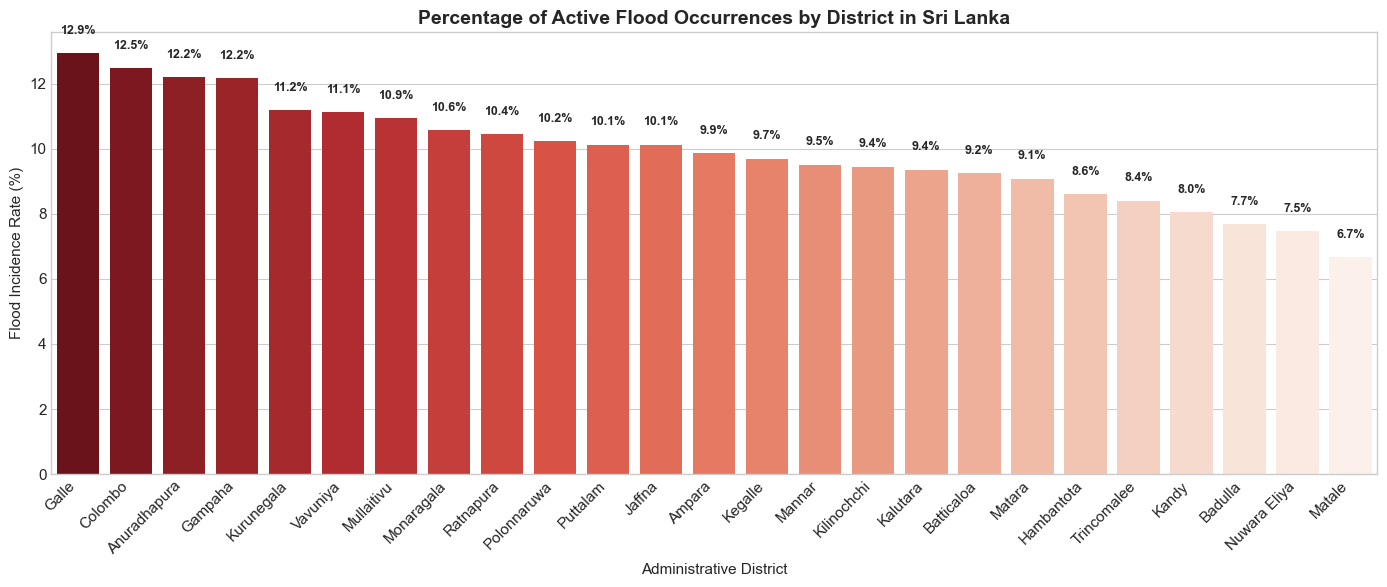

In [146]:
# 3.1 District-Level Flood Incidence Analysis
district_flood = pd.crosstab(
    df['district'], 
    df['flood_occurrence_current_event'], 
    normalize='index'
) * 100

district_flood = district_flood.sort_values(by='Yes', ascending=False)

# Visualizing district flood incidence rates
plt.figure(figsize=(14, 6))
ax = sns.barplot(x=district_flood.index, y=district_flood['Yes'], palette='Reds_r')
plt.title('Percentage of Active Flood Occurrences by District in Sri Lanka', fontsize=14, fontweight='bold')
plt.xlabel('Administrative District', fontsize=11)
plt.ylabel('Flood Incidence Rate (%)', fontsize=11)
plt.xticks(rotation=45, ha='right')

# Annotate bar percentages
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

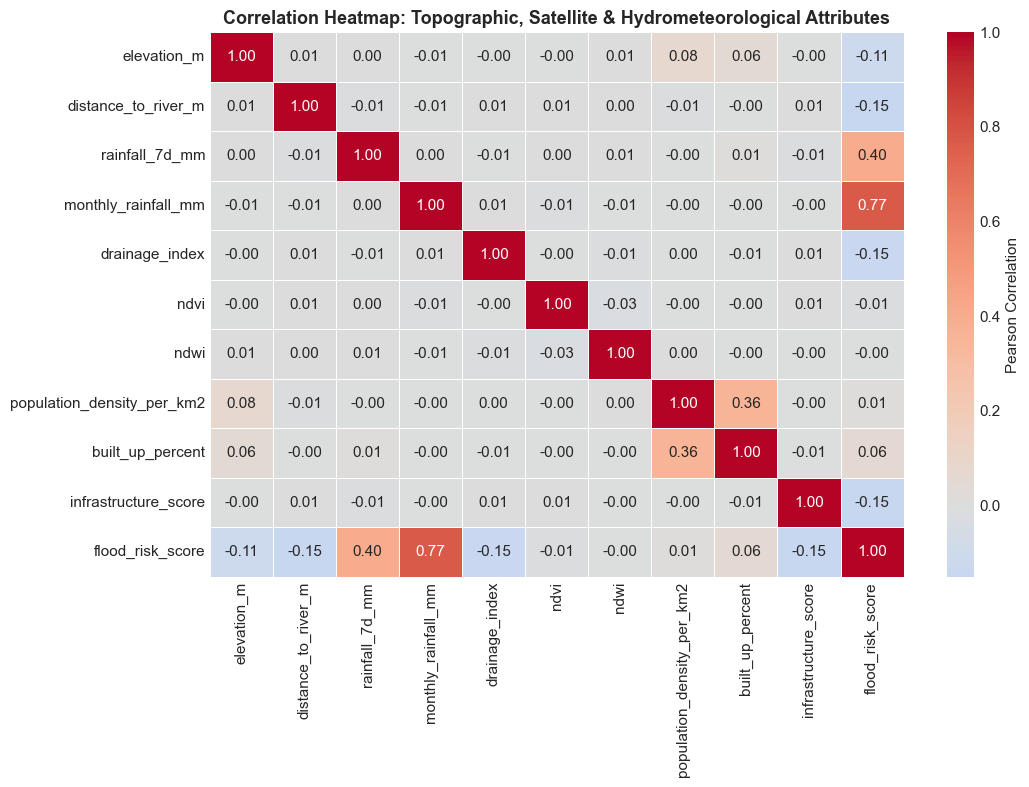

In [147]:
# 3.2 Correlation Heatmap of Numerical Topographic & Hydrologic Features
corr_cols = [
    'elevation_m', 'distance_to_river_m', 'rainfall_7d_mm', 'monthly_rainfall_mm',
    'drainage_index', 'ndvi', 'ndwi', 'population_density_per_km2', 
    'built_up_percent', 'infrastructure_score', 'flood_risk_score'
]

# Compute Pearson correlation matrix
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.5, 
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Correlation Heatmap: Topographic, Satellite & Hydrometeorological Attributes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

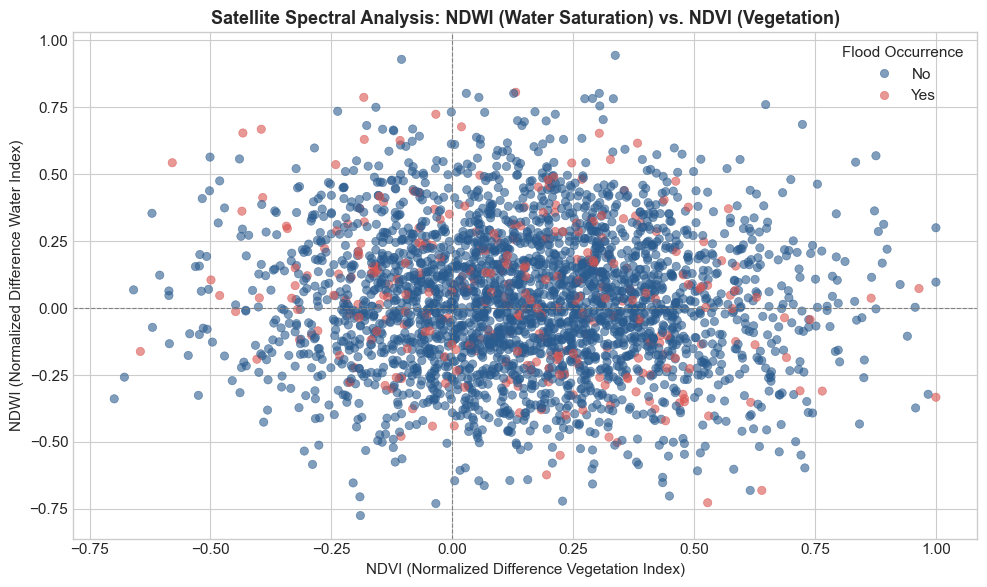

In [148]:
# 3.3 Satellite Earth Observation Analysis: NDWI vs. NDVI
# NDWI (Normalized Difference Water Index) vs NDVI (Normalized Difference Vegetation Index)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(n=3000, random_state=42), # Sample for clean visual clarity
    x='ndvi', 
    y='ndwi', 
    hue='flood_occurrence_current_event', 
    palette={'No': '#2b5c8f', 'Yes': '#d9534f'},
    alpha=0.6,
    edgecolor=None
)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Satellite Spectral Analysis: NDWI (Water Saturation) vs. NDVI (Vegetation)', fontsize=13, fontweight='bold')
plt.xlabel('NDVI (Normalized Difference Vegetation Index)', fontsize=11)
plt.ylabel('NDWI (Normalized Difference Water Index)', fontsize=11)
plt.legend(title='Flood Occurrence', loc='upper right')
plt.tight_layout()
plt.show()

C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\2320653240.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\2320653240.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


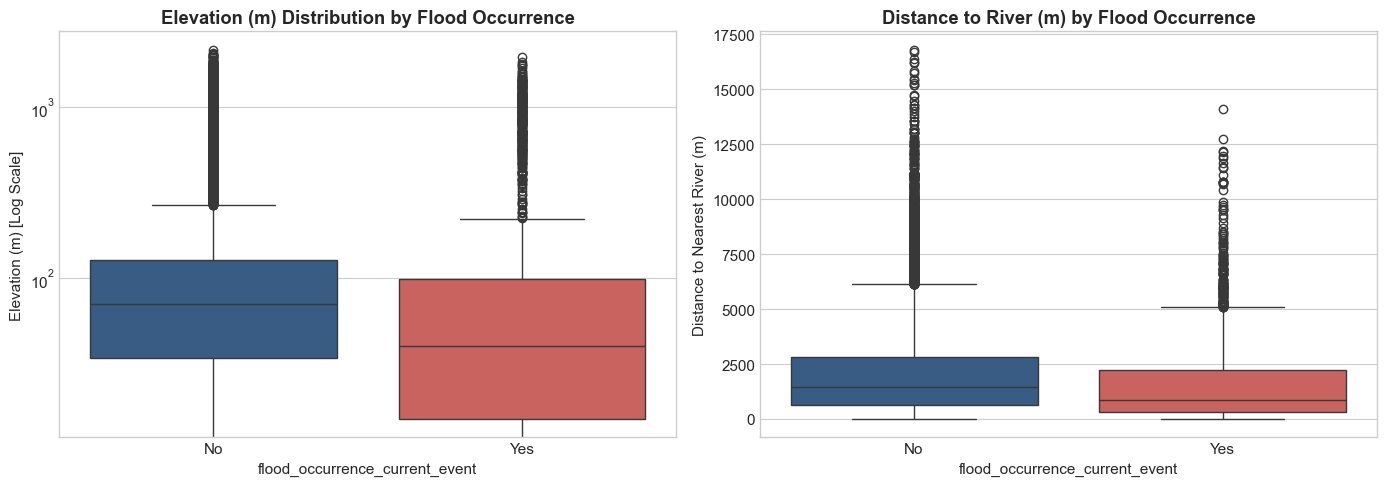

In [149]:
# 3.4 Elevation & River Proximity vs. Flood Occurrence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, 
    x='flood_occurrence_current_event', 
    y='elevation_m', 
    palette=['#2b5c8f', '#d9534f'],
    ax=axes[0]
)
axes[0].set_title('Elevation (m) Distribution by Flood Occurrence', fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Elevation (m) [Log Scale]')

sns.boxplot(
    data=df, 
    x='flood_occurrence_current_event', 
    y='distance_to_river_m', 
    palette=['#2b5c8f', '#d9534f'],
    ax=axes[1]
)
axes[1].set_title('Distance to River (m) by Flood Occurrence', fontweight='bold')
axes[1].set_ylabel('Distance to Nearest River (m)')

plt.tight_layout()
plt.show()

### 3.5 EDA Interpretation
The preceding plots describe synthetic records. They are exploratory, not evidence of measured district-level flood incidence or causal hydrological effects. Predictive value is assessed through training-only benchmarking and the final held-out evaluation.

## Step 4: Data Cleaning & Quality Preprocessing


In this stage, we audit missing values (retaining them to be imputed fold-locally within each training partition to prevent leakage), eliminate non-predictive metadata and target leakage columns, and verify physical domain constraints to produce a sanitized dataset.

In [150]:
# 4.1 Dropping Non-Predictive Metadata & Post-Event Leakage Columns
print(f"Initial dataset shape: {df.shape}")

# Define columns to drop:
# - Non-predictive IDs & metadata: record_id, place_name, is_synthetic, generation_date
# - Post-event target leakage: inundation_area_sqm, is_good_to_live, reason_not_good_to_live
# - Target proxy: flood_risk_score (derived directly from flood event probability)
columns_to_drop = [
    'record_id', 'place_name', 'is_synthetic', 'generation_date',
    'inundation_area_sqm', 'is_good_to_live', 'reason_not_good_to_live',
    'flood_risk_score'
]

df_cleaned = df.drop(columns=columns_to_drop)
print(f"Cleaned dataset shape after column removal: {df_cleaned.shape}")
print(f"Removed columns: {columns_to_drop}")

Initial dataset shape: (25000, 32)
Cleaned dataset shape after column removal: (25000, 24)
Removed columns: ['record_id', 'place_name', 'is_synthetic', 'generation_date', 'inundation_area_sqm', 'is_good_to_live', 'reason_not_good_to_live', 'flood_risk_score']


In [151]:
# 4.2 Missing-value audit: do not learn imputation values before splitting.
remaining_nulls = df_cleaned.isnull().sum()
print(remaining_nulls[remaining_nulls > 0])
print("Missing values are retained here. Imputation is fitted within each training partition.")

class RawDataSanitizer(BaseEstimator, TransformerMixin):
    """Drops non-predictive metadata & post-event leakage; imputes missing electricity & defaults."""
    def __init__(self, electricity_mode='Grid', numerical_defaults=None):
        self.electricity_mode = electricity_mode
        self.numerical_defaults = numerical_defaults
        self.cols_to_drop = [
            'record_id', 'place_name', 'is_synthetic', 'generation_date',
            'inundation_area_sqm', 'is_good_to_live', 'reason_not_good_to_live',
            'flood_risk_score', 'flood_occurrence_current_event', 'target'
        ]

    def fit(self, X, y=None):
        self.electricity_mode_ = self.electricity_mode
        self.numerical_defaults_ = dict(self.numerical_defaults or {})
        if isinstance(X, pd.DataFrame):
            # Exclude leakage/drop columns before learning training distributions
            clean_cols = [c for c in X.columns if c not in self.cols_to_drop]
            X_clean = X[clean_cols]
            if 'electricity' in X_clean.columns:
                modes = X_clean['electricity'].dropna().mode()
                if not modes.empty:
                    self.electricity_mode_ = modes.iloc[0]
            num_cols = X_clean.select_dtypes(include=[np.number]).columns
            self.numerical_defaults_ = X_clean[num_cols].median().to_dict()
        return self

    def transform(self, X):
        X_df = pd.DataFrame([X]) if isinstance(X, dict) else (X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X))
        drop_cols = [c for c in self.cols_to_drop if c in X_df.columns]
        if drop_cols:
            X_df = X_df.drop(columns=drop_cols)
        if 'electricity' in X_df.columns:
            X_df['electricity'] = X_df['electricity'].fillna(self.electricity_mode_)
        else:
            X_df['electricity'] = self.electricity_mode_
        for col, val in self.numerical_defaults_.items():
            if col not in X_df.columns:
                X_df[col] = val
            else:
                X_df[col] = X_df[col].fillna(val)
        return X_df


class HydrologicalFeatureEngineer(BaseEstimator, TransformerMixin):
    """Computes the 6 physical hydrological features dynamically on raw telemetry."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        X_df['hydrological_stress_index'] = X_df['rainfall_7d_mm'] / (X_df['elevation_m'] + 1.0)
        X_df['drainage_saturation_ratio'] = X_df['rainfall_7d_mm'] * (1.0 - X_df['drainage_index'])
        X_df['water_veg_contrast'] = X_df['ndwi'] - X_df['ndvi']
        X_df['river_proximity_buffer'] = np.exp(-X_df['distance_to_river_m'] / 1000.0)
        X_df['log_population_density'] = np.log1p(X_df['population_density_per_km2'])
        X_df['runoff_vulnerability'] = (X_df['built_up_percent'] / 100.0) / (X_df['drainage_index'] + 0.01)
        return X_df

electricity    789
dtype: int64
Missing values are retained here. Imputation is fitted within each training partition.


In [152]:
# 4.3 Outlier Treatment & Sanity Checks
# Inspect distributions of extreme meteorological and demographic features
outlier_candidates = ['rainfall_7d_mm', 'monthly_rainfall_mm', 'population_density_per_km2']

# Check 99th percentiles vs max to ensure physical plausibility
print("Physical Plausibility & 99th Percentile Audit:")
for col in outlier_candidates:
    p99 = df_cleaned[col].quantile(0.99)
    max_val = df_cleaned[col].max()
    min_val = df_cleaned[col].min()
    print(f"- {col:30}: Min={min_val:.1f} | 99th%={p99:.1f} | Max={max_val:.1f}")

# Verify valid physical ranges
assert (df_cleaned['elevation_m'] >= 0).all(), "Invalid negative elevation detected!"
assert (df_cleaned['distance_to_river_m'] >= 0).all(), "Invalid negative river distance detected!"
assert (df_cleaned['rainfall_7d_mm'] >= 0).all(), "Invalid negative rainfall detected!"
print("✓ Physical domain range constraints passed successfully!")

Physical Plausibility & 99th Percentile Audit:
- rainfall_7d_mm                : Min=0.0 | 99th%=247.4 | Max=372.2
- monthly_rainfall_mm           : Min=0.0 | 99th%=573.1 | Max=863.7
- population_density_per_km2    : Min=10.0 | 99th%=2283.0 | Max=3113.0
✓ Physical domain range constraints passed successfully!


In [153]:
# 4.4 Target Variable Binary Encoding
# Encode flood_occurrence_current_event: 'Yes' -> 1, 'No' -> 0
df_cleaned['target'] = df_cleaned['flood_occurrence_current_event'].map({'Yes': 1, 'No': 0})
df_cleaned = df_cleaned.drop(columns=['flood_occurrence_current_event'])

print("Cleaned Data Overview:")
print(f"- Feature Matrix Shape: {df_cleaned.drop(columns=['target']).shape}")
print(f"- Target Vector Shape:  {df_cleaned['target'].shape}")
print(f"- Target Class Distribution (0=No, 1=Yes):")
print(df_cleaned['target'].value_counts())

Cleaned Data Overview:
- Feature Matrix Shape: (25000, 23)
- Target Vector Shape:  (25000,)
- Target Class Distribution (0=No, 1=Yes):
target
0    22528
1     2472
Name: count, dtype: int64


### 4.5 Data Cleaning Summary
Eight identifiers, post-event fields, and target proxies are excluded. Missing electricity values remain unfilled until the training pipeline learns its mode. Numerical defaults are also learned only from the applicable training partition. The same sanitizer is used during cross-validation and exported inference.

## Step 5: Feature Engineering

To equip machine learning models with physical domain knowledge of Sri Lankan hydrology and monsoons, we engineer **6 meaningful domain-specific features**. These transform raw measurements into non-linear indicators of hydrological stress, surface ponding, and topography vulnerability.

In [154]:
# 5.1 Formulation of Domain-Specific Engineered Features
print("Engineering 6 Physical & Hydrological Features...")

# Create a working copy for feature engineering
df_fe = df_cleaned.copy()

# --- Technique 1: Hydrological Stress Index ---
# Physical concept: High cumulative rainfall combined with low elevation leads to severe water stagnation.
df_fe['hydrological_stress_index'] = df_fe['rainfall_7d_mm'] / (df_fe['elevation_m'] + 1.0)

# --- Technique 2: Drainage Saturation Ratio ---
# Physical concept: Rainfall that exceeds natural soil drainage absorption triggers overland runoff.
df_fe['drainage_saturation_ratio'] = df_fe['rainfall_7d_mm'] * (1.0 - df_fe['drainage_index'])

# --- Technique 3: Satellite Water-Vegetation Differential (NDWI - NDVI) ---
# Physical concept: When flood waters submerge vegetation, NDWI spikes positive while NDVI drops.
df_fe['water_veg_contrast'] = df_fe['ndwi'] - df_fe['ndvi']

# --- Technique 4: River Proximity Decay Buffer ---
# Physical concept: Non-linear exponential decay buffer modeling overbank flood risk.
df_fe['river_proximity_buffer'] = np.exp(-df_fe['distance_to_river_m'] / 1000.0)

# --- Technique 5: Log Transformation for Skewed Distributions ---
# Statistical concept: Normalizes extreme heavy-tailed population density distributions.
df_fe['log_population_density'] = np.log1p(df_fe['population_density_per_km2'])

# --- Technique 6: Runoff Vulnerability Score ---
# Physical concept: Impervious built-up surface area versus available natural drainage capacity.
df_fe['runoff_vulnerability'] = (df_fe['built_up_percent'] / 100.0) / (df_fe['drainage_index'] + 0.01)

print(f"✓ 6 Features successfully engineered! New total columns: {df_fe.shape[1]}")
df_fe[[
    'hydrological_stress_index', 'drainage_saturation_ratio', 
    'water_veg_contrast', 'river_proximity_buffer', 
    'log_population_density', 'runoff_vulnerability'
]].head()

Engineering 6 Physical & Hydrological Features...
✓ 6 Features successfully engineered! New total columns: 30


,hydrological_stress_index,drainage_saturation_ratio,water_veg_contrast,river_proximity_buffer,log_population_density,runoff_vulnerability
0,1.582022,91.5200,0.882,0.712340,6.810142,0.694444
1,2.145763,81.0240,0.083,0.284336,6.086775,0.743243
2,1.914815,42.1872,-0.666,0.005379,4.919981,0.050136
3,0.090179,7.1912,-0.698,0.052319,6.593045,0.546980
4,1.337037,20.3965,0.236,0.795885,6.068426,0.485393


=== FEATURE DISCRIMINATIVE POWER ===
                           Mean (No Flood)  Mean (Active Flood)  \
hydrological_stress_index         2.683496             9.675414   
drainage_saturation_ratio        36.855944            70.137899   
water_veg_contrast               -0.136283            -0.135697   
river_proximity_buffer            0.319149             0.442758   
log_population_density            5.974909             6.034617   
runoff_vulnerability              0.688191             0.826288   

                           Ratio (Flood / No Flood)  
hydrological_stress_index                      3.61  
drainage_saturation_ratio                      1.90  
water_veg_contrast                             1.00  
river_proximity_buffer                         1.39  
log_population_density                         1.01  
runoff_vulnerability                           1.20  


C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\2346708567.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\2346708567.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Flood (0)', 'Active Flood (1)'])
C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\2346708567.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\2346708567.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].se

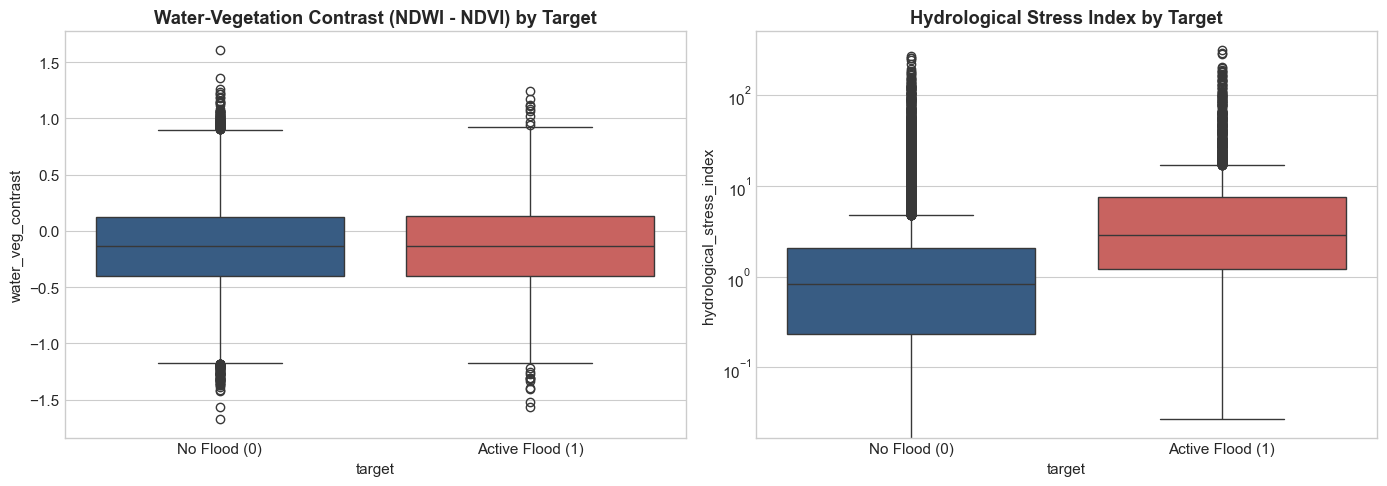

In [155]:
# 5.2 Statistical Validation of Engineered Features vs. Target
engineered_cols = [
    'hydrological_stress_index', 'drainage_saturation_ratio', 
    'water_veg_contrast', 'river_proximity_buffer', 
    'log_population_density', 'runoff_vulnerability'
]

# Compare feature means between Flooded (target=1) and Non-Flooded (target=0)
comparison = df_fe.groupby('target')[engineered_cols].mean().T
comparison.columns = ['Mean (No Flood)', 'Mean (Active Flood)']
comparison['Ratio (Flood / No Flood)'] = (comparison['Mean (Active Flood)'] / comparison['Mean (No Flood)']).round(2)
print("=== FEATURE DISCRIMINATIVE POWER ===")
print(comparison)

# Visualizing the separation achieved by engineered features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_fe, 
    x='target', 
    y='water_veg_contrast', 
    palette=['#2b5c8f', '#d9534f'],
    ax=axes[0]
)
axes[0].set_title('Water-Vegetation Contrast (NDWI - NDVI) by Target', fontweight='bold')
axes[0].set_xticklabels(['No Flood (0)', 'Active Flood (1)'])

sns.boxplot(
    data=df_fe, 
    x='target', 
    y='hydrological_stress_index', 
    palette=['#2b5c8f', '#d9534f'],
    ax=axes[1]
)
axes[1].set_title('Hydrological Stress Index by Target', fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_xticklabels(['No Flood (0)', 'Active Flood (1)'])

plt.tight_layout()
plt.show()

### 5.3 Feature Engineering Summary
The six features use fixed, row-wise formulas and do not estimate parameters from other records. Step 5 illustrates their distributions; the training pipeline recomputes them from raw inputs. District is one-hot encoded, not target encoded. These heuristics require validation on observed flood data before their physical usefulness can be established.

## Step 6: Dataset Splitting 

### 6.1 Data Leakage Prevention Principles
In predictive disaster analytics, **data leakage** occurs when information from outside the training dataset is used to create or tune the model. To guarantee pure out-of-sample evaluation:
1. **Splitting occurs BEFORE any feature scaling, one-hot encoding, or parameter estimation.**
2. **Stratified Sampling** is strictly enforced to ensure the 9.89% flood event ratio is identically maintained across Train (70%), Validation (15%), and Test (15%) partitions.

In [156]:
from sklearn.model_selection import train_test_split

# Separate Feature Matrix (X) and Target Vector (y)
X = df.drop(columns=['flood_occurrence_current_event'])
y = df['flood_occurrence_current_event'].map({'Yes': 1, 'No': 0})
assert y.notna().all(), 'Unknown or missing target label'

# First Split: 70% Train, 30% Temporary (Validation + Test) with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# Second Split: Partition Temporary 30% evenly into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

# Verify split dimensions and class distribution balance
split_summary = pd.DataFrame({
    'Dataset Partition': ['Train Set (70%)', 'Validation Set (15%)', 'Test Set (15%)'],
    'Total Records': [len(X_train), len(X_val), len(X_test)],
    'Negative Class (0 - No Flood)': [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    'Positive Class (1 - Flood)': [(y_train == 1).sum(), (y_val == 1).sum(), (y_test == 1).sum()],
    'Flood Event Ratio (%)': [
        (y_train.mean() * 100).round(2),
        (y_val.mean() * 100).round(2),
        (y_test.mean() * 100).round(2)
    ]
})

print("=== STRATIFIED DATASET SPLIT VERIFICATION ===")
print(split_summary.to_string(index=False))

# Verify zero overlap across indices
assert len(set(X_train.index).intersection(set(X_val.index))) == 0, "Data leakage: Overlap between Train and Val!"
assert len(set(X_train.index).intersection(set(X_test.index))) == 0, "Data leakage: Overlap between Train and Test!"
assert len(set(X_val.index).intersection(set(X_test.index))) == 0, "Data leakage: Overlap between Val and Test!"
print("✓ Zero partition overlap verified. Dataset splitting completed with 100% integrity!")

=== STRATIFIED DATASET SPLIT VERIFICATION ===
   Dataset Partition  Total Records  Negative Class (0 - No Flood)  Positive Class (1 - Flood)  Flood Event Ratio (%)
     Train Set (70%)          17500                          15770                        1730                   9.89
Validation Set (15%)           3750                           3379                         371                   9.89
      Test Set (15%)           3750                           3379                         371                   9.89
✓ Zero partition overlap verified. Dataset splitting completed with 100% integrity!


### 6.2 Partition Protocol
The split contains 17,500 training, 3,750 validation, and 3,750 test records, with disjoint indices. All learned transformations are fitted on training rows only, including within CV folds. Validation is reserved for calibration and threshold selection. Test predictions are first computed after the final model and threshold have been fixed. Random stratification estimates performance on this synthetic distribution; it does not establish spatial or future-event generalization.

## Step 7: Algorithm Selection & Multi-Model Benchmarking

### 7.1 Architectural Diversity & Scientific Benchmarking Justification
To rigorously justify our final model choice for the Sri Lanka Flood Early Warning System, we benchmark **5 diverse machine learning algorithms** across three distinct structural families:

1. **Logistic Regression (L2 Regularized Baseline):**
   - *Model Family:* Parametric Generalized Linear Model (GLM).
   - *Rationale:* Establishes an interpretable linear baseline with balanced class weights to verify whether flood risk requires complex non-linear boundary separation.

2. **Random Forest Classifier:**
   - *Model Family:* Bagging Ensemble (Bootstrap Aggregation).
   - *Rationale:* Trains parallel, de-correlated decision trees with balanced subsampling to test whether reducing model variance resolves flood classification challenges.

3. **XGBoost Classifier (Extreme Gradient Boosting):**
   - *Model Family:* Level-wise Gradient Boosting.
   - *Rationale:* Sequential tree boosting utilizing second-order Taylor gradients with `scale_pos_weight ≈ 9.12` to aggressively optimize for the rare positive flood class.

4. **LightGBM Classifier:**
   - *Model Family:* Leaf-wise Histogram Boosting.
   - *Rationale:* Bins continuous variables into discrete histograms and grows trees leaf-wise, delivering ultra-fast training and exceptional recall sensitivity on hydrological tabular data.

5. **CatBoost Classifier:**
   - *Model Family:* Ordered Boosting with Oblivious Trees.
   - *Rationale:* Uses symmetric trees with the same one-hot encoded inputs as the other candidates for a consistent comparison; native categorical encoding is not used here.

In [157]:
# 7.2 Shared preprocessing pipeline, fitted on training rows only.
from sklearn.base import clone

categorical_cols = [
    'district', 'landcover', 'soil_type', 'water_supply',
    'electricity', 'road_quality', 'urban_rural', 'water_presence_flag'
]
# Column names come from the known feature schema, not fitted distributions.
numerical_cols = [col for col in df_fe.columns
                  if col not in categorical_cols + ['target']]
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])
preprocessing_template = Pipeline([
    ('sanitizer', RawDataSanitizer()),
    ('feature_engineer', HydrologicalFeatureEngineer()),
    ('preprocessor', preprocessor)
])

def model_pipeline(model):
    return Pipeline([('preprocessing', clone(preprocessing_template)),
                     ('model', clone(model))])

fitted_preprocessing = clone(preprocessing_template)
X_train_proc = fitted_preprocessing.fit_transform(X_train, y_train)
X_val_proc = fitted_preprocessing.transform(X_val)
print(f'Training matrix: {X_train_proc.shape}')

Training matrix: (17500, 74)


In [158]:
# 7.3 Multi-Model Benchmarking Execution
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    f1_score, recall_score, precision_score
)

# Calculate positive class weight ratio: (negative_count / positive_count)
scale_pos_weight_val = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Class Imbalance Ratio (scale_pos_weight): {scale_pos_weight_val:.2f}")

# Define the 5 candidate architectures with balanced class weighting
candidate_models = {
    "Logistic Regression (L2 Baseline)": LogisticRegression(
        penalty='l2', C=1.0, class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Random Forest (Bagging)": RandomForestClassifier(
        n_estimators=150, max_depth=12, class_weight='balanced', n_jobs=-1, random_state=42
    ),
    "XGBoost (Gradient Boosting)": XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.05, 
        scale_pos_weight=scale_pos_weight_val, eval_metric='logloss', 
        n_jobs=-1, random_state=42
    ),
    "LightGBM (Histogram Boosting)": LGBMClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.05, 
        scale_pos_weight=scale_pos_weight_val, n_jobs=-1, random_state=42, verbose=-1
    ),
    "CatBoost (Ordered Boosting)": CatBoostClassifier(
        iterations=150, depth=6, learning_rate=0.05, 
        auto_class_weights='Balanced', verbose=0, random_seed=42, allow_writing_files=False
    )
}

# Benchmark only within training data; leave validation for calibration/thresholds.
X_bench_train, X_bench_val, y_bench_train, y_bench_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=42
)
# Each candidate fits its own preprocessing on the inner training subset.

benchmark_records = []
fitted_models = {}

print("\nBenchmarking 5 Candidate Architectures:")
for name, candidate in candidate_models.items():
    model = model_pipeline(candidate)
    # Measure Training Time
    t_start = time.time()
    model.fit(X_bench_train, y_bench_train)
    t_train = time.time() - t_start
    fitted_models[name] = model
    
    # Measure Inference Latency (ms per sample)
    t_infer_start = time.time()
    y_pred_proba = model.predict_proba(X_bench_val)[:, 1]
    latency = ((time.time() - t_infer_start) / len(X_bench_val)) * 1000.0
    
    # Thresholded predictions
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Evaluate performance metrics
    pr_auc = average_precision_score(y_bench_val, y_pred_proba)
    roc_auc = roc_auc_score(y_bench_val, y_pred_proba)
    rec = recall_score(y_bench_val, y_pred)
    prec = precision_score(y_bench_val, y_pred, zero_division=0)
    f1 = f1_score(y_bench_val, y_pred, zero_division=0)
    
    benchmark_records.append({
        'Model': name,
        'PR-AUC': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Recall (Flood)': round(rec, 4),
        'Precision': round(prec, 4),
        'F1-Score': round(f1, 4),
        'Train Time (s)': round(t_train, 2),
        'Latency (ms)': round(latency, 3)
    })
    print(f"✓ {name:32} | PR-AUC: {pr_auc:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

# Construct benchmark comparison table
benchmark_df = pd.DataFrame(benchmark_records).sort_values(by='PR-AUC', ascending=False)
print("\n=== MULTI-MODEL BENCHMARK RESULTS ===")
benchmark_df

Class Imbalance Ratio (scale_pos_weight): 9.12

Benchmarking 5 Candidate Architectures:
✓ Logistic Regression (L2 Baseline) | PR-AUC: 0.5970 | Recall: 0.9017 | F1: 0.5617


c:\Users\gamit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


✓ Random Forest (Bagging)          | PR-AUC: 0.6073 | Recall: 0.8844 | F1: 0.6408
✓ XGBoost (Gradient Boosting)      | PR-AUC: 0.6087 | Recall: 0.9624 | F1: 0.6517
✓ LightGBM (Histogram Boosting)    | PR-AUC: 0.6097 | Recall: 0.9480 | F1: 0.6534
✓ CatBoost (Ordered Boosting)      | PR-AUC: 0.6572 | Recall: 0.9855 | F1: 0.6217

=== MULTI-MODEL BENCHMARK RESULTS ===


,Model,PR-AUC,ROC-AUC,Recall (Flood),Precision,F1-Score,Train Time (s),Latency (ms)
4,CatBoost (Ordered Boosting),0.6572,0.9619,0.9855,0.4541,0.6217,1.30,0.005
3,LightGBM (Histogram Boosting),0.6097,0.9574,0.9480,0.4985,0.6534,0.31,0.008
2,XGBoost (Gradient Boosting),0.6087,0.9573,0.9624,0.4926,0.6517,0.36,0.006
1,Random Forest (Bagging),0.6073,0.9543,0.8844,0.5025,0.6408,0.44,0.016
0,Logistic Regression (L2 Baseline),0.5970,0.9427,0.9017,0.4078,0.5617,0.16,0.004


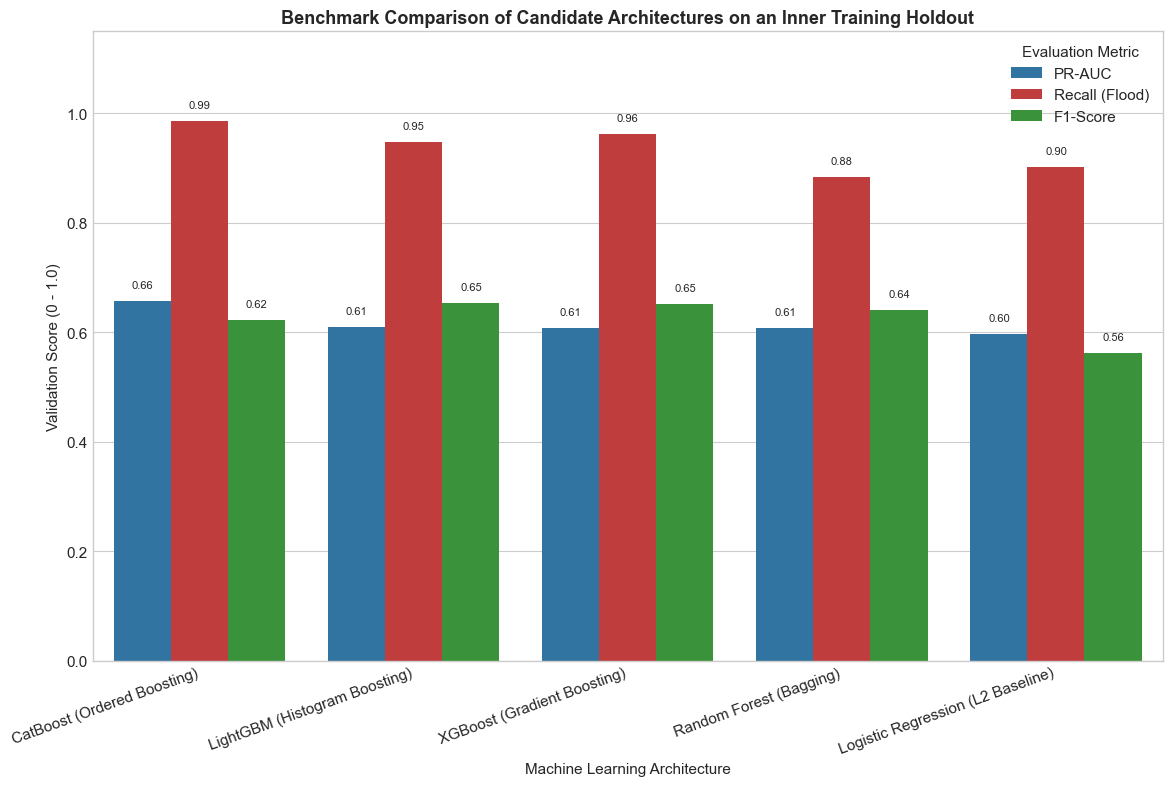

In [159]:
# 7.4 Benchmark Visualization: PR-AUC, Recall & F1-Score
plt.figure(figsize=(12, 8))
metrics_to_plot = ['PR-AUC', 'Recall (Flood)', 'F1-Score']
plot_data = benchmark_df.melt(id_vars='Model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

ax = sns.barplot(data=plot_data, x='Model', y='Score', hue='Metric', palette=['#1f77b4', '#d62728', '#2ca02c'])
plt.title('Benchmark Comparison of Candidate Architectures on an Inner Training Holdout', fontsize=13, fontweight='bold')
plt.xlabel('Machine Learning Architecture', fontsize=11)
plt.ylabel('Validation Score (0 - 1.0)', fontsize=11)
plt.ylim(0, 1.15)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Evaluation Metric', loc='upper right')

# Add data labels above bars
for p in ax.patches:
    h = p.get_height()
    if h > 0.05:
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h + 0.02),
                    ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

### 7.5 Interpreting the Benchmark
All five models use the same inner training holdout and one-hot categorical encoding, including CatBoost. The table reports average precision (AP, labelled PR-AUC throughout this notebook), recall, and F1. Batch time per record is not a measurement of single-request API latency. XGBoost is the preselected model for the tuning exercise; the benchmark does not automatically select a winner.

## Step 8: Model Training & 5-Fold Stratified Cross-Validation

### 8.1 Rigorous Generalization Protocol via Stratified K-Fold
To measure variability across random subsets of the synthetic training data, we conduct **5-Fold Stratified Cross-Validation**.
Each fold maintains the precise 9.89% flood class ratio, ensuring unbiased estimation of out-of-fold generalization.

In [160]:
# 8.2 Five-fold CV of all five complete pipelines on raw training rows.
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {name: clone(model) for name, model in candidate_models.items()}
cv_results = []
for name, model in cv_models.items():
    scores = cross_validate(
        model_pipeline(model), X_train, y_train, cv=skf,
        scoring={'ap': 'average_precision', 'roc': 'roc_auc', 'recall': 'recall'},
        n_jobs=1, error_score='raise'
    )
    cv_results.append({
        'Model': name,
        'PR-AUC (Mean ± Std)': f"{scores['test_ap'].mean():.4f} ± {scores['test_ap'].std():.4f}",
        'ROC-AUC (Mean ± Std)': f"{scores['test_roc'].mean():.4f} ± {scores['test_roc'].std():.4f}",
        'Recall (Mean ± Std)': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}"
    })
    print(f"{name}: mean CV AP = {scores['test_ap'].mean():.4f}", flush=True)
pd.DataFrame(cv_results)

c:\Users\gamit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gamit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression (L2 Baseline): mean CV AP = 0.5546


c:\Users\gamit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Random Forest (Bagging): mean CV AP = 0.5856
XGBoost (Gradient Boosting): mean CV AP = 0.5960
LightGBM (Histogram Boosting): mean CV AP = 0.5977
CatBoost (Ordered Boosting): mean CV AP = 0.6205


,Model,PR-AUC (Mean ± Std),ROC-AUC (Mean ± Std),Recall (Mean ± Std)
0,Logistic Regression (L2 Baseline),0.5546 ± 0.0186,0.9394 ± 0.0034,0.9006 ± 0.0118
1,Random Forest (Bagging),0.5856 ± 0.0143,0.9508 ± 0.0031,0.8387 ± 0.0226
2,XGBoost (Gradient Boosting),0.5960 ± 0.0177,0.9554 ± 0.0026,0.9098 ± 0.0072
3,LightGBM (Histogram Boosting),0.5977 ± 0.0225,0.9559 ± 0.0030,0.9110 ± 0.0166
4,CatBoost (Ordered Boosting),0.6205 ± 0.0184,0.9589 ± 0.0034,0.9746 ± 0.0059


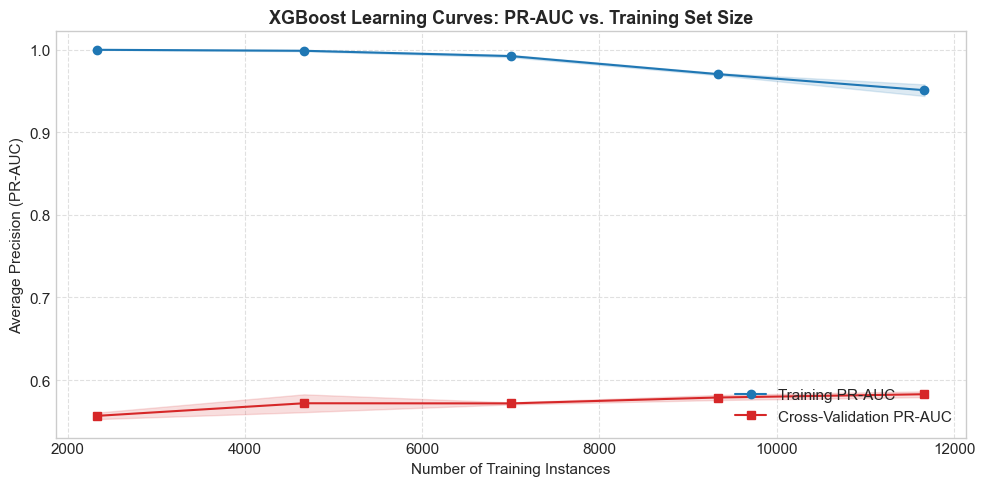

In [161]:
# 8.3 Learning Curves: Diagnosing Bias vs. Variance
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_pipeline(candidate_models['XGBoost (Gradient Boosting)']),
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    shuffle=True,
    scoring='average_precision',
    n_jobs=1,  # XGBoost already parallelizes each fit; avoid nested worker pools.
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', label='Training PR-AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')

plt.plot(train_sizes, val_mean, 's-', color='#d62728', label='Cross-Validation PR-AUC')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#d62728')

plt.title('XGBoost Learning Curves: PR-AUC vs. Training Set Size', fontsize=13, fontweight='bold')
plt.xlabel('Number of Training Instances', fontsize=11)
plt.ylabel('Average Precision (PR-AUC)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

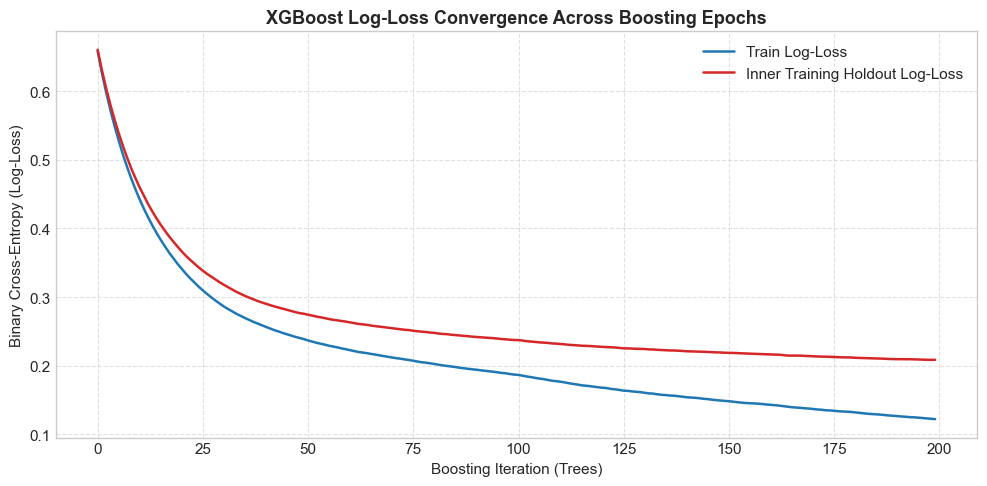

In [162]:
# 8.4 Boosting Loss Convergence Tracking
# Train XGBoost with evaluation tracking across boosting epochs
xgb_eval = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05, 
    scale_pos_weight=scale_pos_weight_val, eval_metric=['logloss', 'error'], 
    random_state=42
)

loss_preprocessing = clone(preprocessing_template)
X_loss_train = loss_preprocessing.fit_transform(X_bench_train, y_bench_train)
X_loss_val = loss_preprocessing.transform(X_bench_val)
xgb_eval.fit(
    X_loss_train, y_bench_train,
    eval_set=[(X_loss_train, y_bench_train), (X_loss_val, y_bench_val)],
    verbose=False
)

evals_result = xgb_eval.evals_result()
epochs = len(evals_result['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, evals_result['validation_0']['logloss'], label='Train Log-Loss', color='#1f77b4', linewidth=1.8)
plt.plot(x_axis, evals_result['validation_1']['logloss'], label='Inner Training Holdout Log-Loss', color='#d62728', linewidth=1.8)
plt.title('XGBoost Log-Loss Convergence Across Boosting Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Boosting Iteration (Trees)', fontsize=11)
plt.ylabel('Binary Cross-Entropy (Log-Loss)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

### 8.5 Interpreting Training Diagnostics
CV refits the sanitizer, feature engineering, encoder, scaler, and classifier separately in every fold. The learning curve applies the same rule to each training size. Loss tracking uses an inner training holdout. Consult the actual tables and curves for variability and overfitting; neither low variance across random folds nor synthetic-data performance establishes generalization to real flood events.

## Step 9: Baseline Evaluation on Out-of-Fold Training Predictions
Generate baseline predictions for each training record using a model that did not fit on that fold. These development diagnostics leave both calibration/threshold validation data and the final test set untouched. False negatives carry a chosen illustrative cost of 10 versus 1 for false positives.

In [163]:
# ============================================================
# 9.1 Final Architecture Selection & Hold-Out Test Evaluation
# ============================================================
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, fbeta_score
)

# Baseline development metrics from fold-local pipelines.
from sklearn.model_selection import cross_val_predict
final_model = clone(candidate_models['XGBoost (Gradient Boosting)'])
y_audit = y_train
y_audit_proba = cross_val_predict(
    model_pipeline(final_model), X_train, y_train, cv=skf,
    method='predict_proba', n_jobs=1
)[:, 1]
# Fixed baseline is also fitted now for the final comparison after tuning.
final_model.fit(X_train_proc, y_train)

y_audit_pred = (y_audit_proba >= 0.50).astype(int)

print("=== TRAINING OOF CLASSIFICATION REPORT (threshold = 0.50) ===")
print(classification_report(y_audit, y_audit_pred,
                            target_names=['No Flood (0)', 'Active Flood (1)']))

audit_metrics_base = {
    'PR-AUC'          : average_precision_score(y_audit, y_audit_proba),
    'ROC-AUC'         : roc_auc_score(y_audit, y_audit_proba),
    'Recall (Flood)'  : recall_score(y_audit, y_audit_pred),
    'Precision'       : precision_score(y_audit, y_audit_pred),
    'F1-Score'        : f1_score(y_audit, y_audit_pred),
    'F2-Score'        : fbeta_score(y_audit, y_audit_pred, beta=2.0)
}
print("=== RAW TRAINING OOF METRICS ===")
print(pd.Series(audit_metrics_base).round(4).to_string())

=== TRAINING OOF CLASSIFICATION REPORT (threshold = 0.50) ===
                  precision    recall  f1-score   support

    No Flood (0)       0.99      0.91      0.95     15770
Active Flood (1)       0.51      0.91      0.66      1730

        accuracy                           0.91     17500
       macro avg       0.75      0.91      0.80     17500
    weighted avg       0.94      0.91      0.92     17500

=== RAW TRAINING OOF METRICS ===
PR-AUC            0.5924
ROC-AUC           0.9553
Recall (Flood)    0.9098
Precision         0.5149
F1-Score          0.6576
F2-Score          0.7888


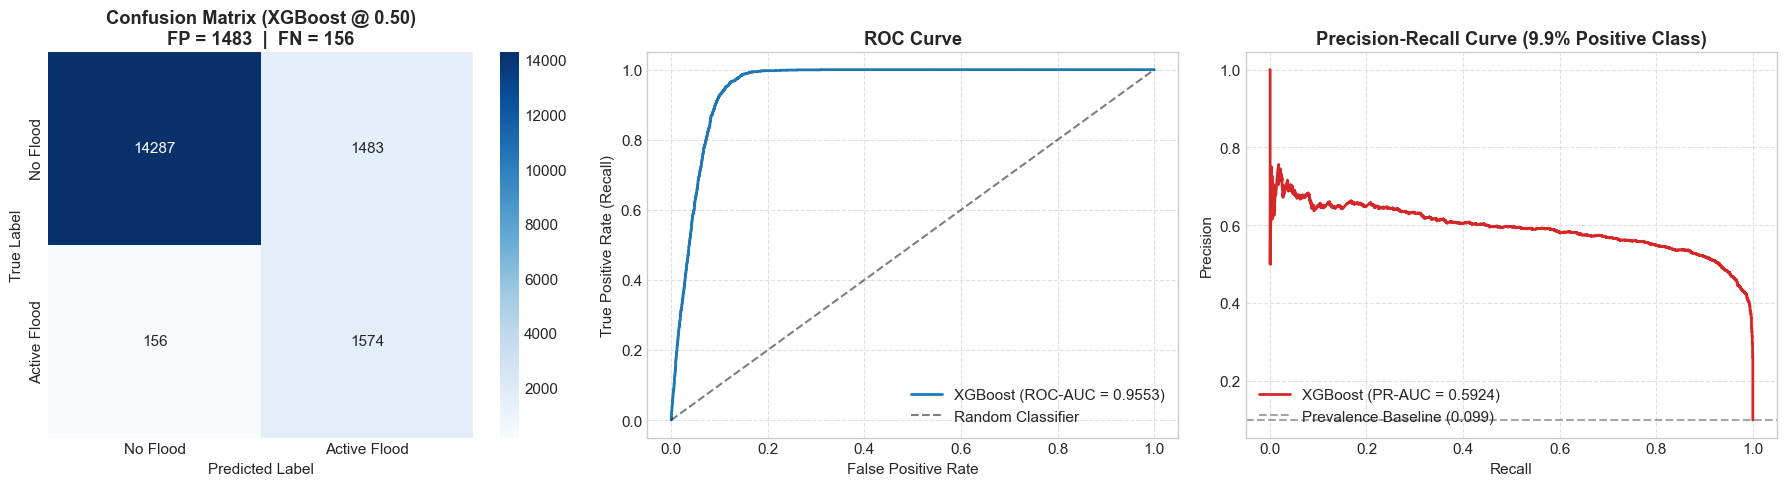

In [164]:
# ============================================================
# 9.2 Confusion Matrix, ROC Curve & Precision-Recall Curve
# ============================================================
cm = confusion_matrix(y_audit, y_audit_pred)
fpr, tpr, _ = roc_curve(y_audit, y_audit_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_audit, y_audit_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Flood', 'Active Flood'],
            yticklabels=['No Flood', 'Active Flood'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title(f'Confusion Matrix (XGBoost @ 0.50)\nFP = {cm[0,1]}  |  FN = {cm[1,0]}',
                  fontweight='bold')

# --- Panel 2: ROC Curve ---
axes[1].plot(fpr, tpr, color='#1f77b4', linewidth=2,
             label=f"XGBoost (ROC-AUC = {audit_metrics_base['ROC-AUC']:.4f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Panel 3: Precision-Recall Curve (honest metric for 9.9% imbalance) ---
axes[2].plot(rec_curve, prec_curve, color='#d62728', linewidth=2,
             label=f"XGBoost (PR-AUC = {audit_metrics_base['PR-AUC']:.4f})")
baseline_prev = y_audit.mean()
axes[2].axhline(baseline_prev, color='gray', linestyle='--', alpha=0.7,
                label=f'Prevalence Baseline ({baseline_prev:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve (9.9% Positive Class)', fontweight='bold')
axes[2].legend(loc='lower left')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

=== DISASTER COST MATRIX ANALYSIS (17,500 Training OOF Records | FP=1, FN=10) ===
                                  Strategy   TP    TN    FP   FN  Recall  Precision  Expected Disaster Cost
                  XGBoost @ threshold 0.50 1574 14287  1483  156  0.9098     0.5149                  3043.0
       Always Negative (No Alert Baseline)    0 15770     0 1730  0.0000     0.0000                 17300.0
Always Positive (Full Evacuation Baseline) 1730     0 15770    0  1.0000     0.0989                 15770.0


C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\93469945.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cost_df, x='Strategy', y='Expected Disaster Cost',
C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\93469945.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')


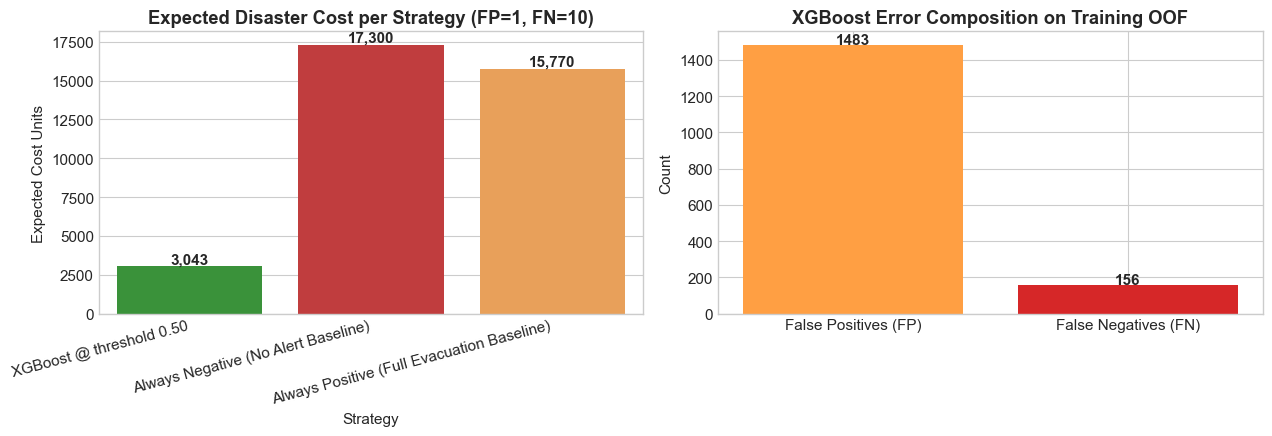

In [165]:
# ============================================================
# 9.3 Asymmetric Disaster Cost Matrix (FN penalized 10x over FP)
# ============================================================
FP_COST = 1.0    # False Alarm  -> unnecessary evacuation, economic friction
FN_COST = 10.0   # Missed Flood -> loss of lives & property (10x heavier)

def disaster_cost_report(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Strategy'              : label,
        'TP'                    : tp,
        'TN'                    : tn,
        'FP'                    : fp,
        'FN'                    : fn,
        'Recall'                : round(recall_score(y_true, y_pred), 4),
        'Precision'             : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Expected Disaster Cost': fp * FP_COST + fn * FN_COST
    }

cost_rows = [
    disaster_cost_report(y_audit, y_audit_pred,               'XGBoost @ threshold 0.50'),
    disaster_cost_report(y_audit, np.zeros_like(y_audit),     'Always Negative (No Alert Baseline)'),
    disaster_cost_report(y_audit, np.ones_like(y_audit),      'Always Positive (Full Evacuation Baseline)')
]
cost_df = pd.DataFrame(cost_rows)

print("=== DISASTER COST MATRIX ANALYSIS (17,500 Training OOF Records | FP=1, FN=10) ===")
print(cost_df.to_string(index=False))

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=cost_df, x='Strategy', y='Expected Disaster Cost',
            palette=['#2ca02c', '#d62728', '#ff9f43'], ax=axes[0])
axes[0].set_title('Expected Disaster Cost per Strategy (FP=1, FN=10)', fontweight='bold')
axes[0].set_ylabel('Expected Cost Units')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

axes[1].bar(['False Positives (FP)', 'False Negatives (FN)'],
            [cm[0, 1], cm[1, 0]], color=['#ff9f43', '#d62728'])
for i, v in enumerate([cm[0, 1], cm[1, 0]]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].set_title('XGBoost Error Composition on Training OOF', fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 9.4 Baseline Evaluation Notes
These are out-of-fold training diagnostics, not final test metrics. Average precision is compared with positive-class prevalence. The cost matrix is an illustrative project assumption. Neither high recall nor reduced cost on synthetic records establishes an operational evacuation policy.

## Step 10: Model Improvement — Optuna Tuning, Calibration & Threshold Shifting

Step 10 systematically improves the Step 9 baseline through three techniques:

1. **Optuna Bayesian (TPE) Hyperparameter Optimization** — maximizing training CV PR-AUC with fold-local preprocessing. *(Run time: a few minutes.)*
2. **Isotonic Probability Calibration** — fitting on a dedicated calibration subset of the Validation set so predicted probabilities reflect true flood likelihoods.
3. **Threshold Shifting** — lowering the decision threshold until **Flood Recall ≥ 90%** is achieved while maximizing the recall-weighted **F2-score**.

> **Leakage-free protocol:** the Validation set is split into two independent halves — one strictly for calibration fitting, the other strictly for threshold selection. The Test set is only touched for the final audit.

In [166]:
# ============================================================
# 10.1 Optuna Bayesian (TPE) Hyperparameter Optimization
# Objective: maximize 3-Fold Stratified CV PR-AUC
# ============================================================
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"Class imbalance ratio (scale_pos_weight upper bound): {scale_pos_weight_val:.2f}")

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 150, 400, step=50),
        'max_depth'       : trial.suggest_int('max_depth', 3, 9),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'           : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight_val),
    }
    model = XGBClassifier(**params, eval_metric='logloss', n_jobs=-1, random_state=42)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model_pipeline(model), X_train, y_train, cv=cv,
                             scoring='average_precision', n_jobs=1, error_score='raise')
    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='xgb_flood_pr_auc_tuning'
)
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("\n=== OPTUNA OPTIMIZATION COMPLETE ===")
print(f"Best Training CV PR-AUC: {study.best_value:.4f}")
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  - {k:18}: {v if isinstance(v, int) else round(v, 6)}")

Class imbalance ratio (scale_pos_weight upper bound): 9.12


Best trial: 20. Best value: 0.619991: 100%|██████████| 25/25 [00:40<00:00,  1.61s/it]


=== OPTUNA OPTIMIZATION COMPLETE ===
Best Training CV PR-AUC: 0.6200
Best Hyperparameters:
  - n_estimators      : 400
  - max_depth         : 3
  - learning_rate     : 0.025009
  - min_child_weight  : 2
  - subsample         : 0.60953
  - colsample_bytree  : 0.81117
  - gamma             : 1.835567
  - reg_alpha         : 0.0
  - reg_lambda        : 0.002655
  - scale_pos_weight  : 3.655419


In [167]:
# 10.2 Fit the selected hyperparameters on training data only.
tuned_model = XGBClassifier(**study.best_params, eval_metric='logloss',
                            n_jobs=-1, random_state=42)
tuned_model.fit(X_train_proc, y_train)

def evaluate_configuration(y_true, y_proba, threshold, label):
    """Full cost-sensitive evaluation of one model+threshold configuration."""
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Configuration': label,
        'Threshold'    : round(threshold, 3),
        'PR-AUC'       : round(average_precision_score(y_true, y_proba), 4),
        'ROC-AUC'      : round(roc_auc_score(y_true, y_proba), 4),
        'Recall'       : round(recall_score(y_true, y_pred), 4),
        'Precision'    : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'F1'           : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'F2'           : round(fbeta_score(y_true, y_pred, beta=2.0, zero_division=0), 4),
        'FP'           : fp,
        'FN'           : fn,
        'Disaster Cost': fp * FP_COST + fn * FN_COST
    }

print("Tuned model fitted. Test set remains unscored until the threshold is fixed.")

Tuned model fitted. Test set remains unscored until the threshold is fixed.


Calibration subset      : 1,875 records
Threshold-tuning subset : 1,875 records


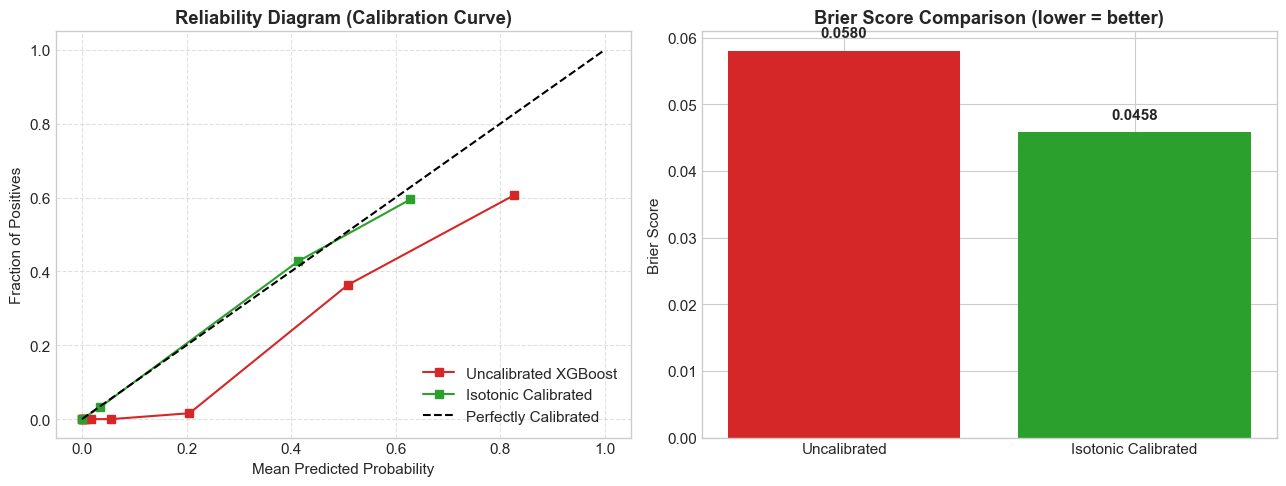

In [168]:
# ============================================================
# 10.3 Probability Calibration (Isotonic Regression)
# ------------------------------------------------------------
# scikit-learn >= 1.8 removed the cv='prefit' option from
# CalibratedClassifierCV. We implement the prefit isotonic
# calibration directly with IsotonicRegression (identical math),
# wrapped in a small class so all downstream cells keep working.
# ============================================================
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

# Split Validation set into CALIBRATION half and THRESHOLD-TUNING half
X_calib, X_thresh, y_calib, y_thresh = train_test_split(
    X_val_proc, y_val, test_size=0.5, random_state=42, stratify=y_val
)
print(f"Calibration subset      : {len(y_calib):,} records")
print(f"Threshold-tuning subset : {len(y_thresh):,} records")

# 1) Raw probabilities of the tuned model on the calibration subset
y_calib_proba_raw = tuned_model.predict_proba(X_calib)[:, 1]

# 2) Fit isotonic regression: raw probability -> true label.
#    This is exactly what method='isotonic' + cv='prefit' did internally.
isotonic_calibrator = IsotonicRegression(out_of_bounds='clip')
isotonic_calibrator.fit(y_calib_proba_raw, y_calib)

# 3) Small wrapper that keeps the usual .predict_proba(X) API so that all
#    downstream cells (reliability diagram, threshold tuning, final audit)
#    work without modification.
class CalibratedModel:
    def __init__(self, base_model, calibrator):
        self.base_model = base_model
        self.calibrator = calibrator

    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        calibrated = self.calibrator.predict(raw)
        return np.column_stack([1 - calibrated, calibrated])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

calibrated_model = CalibratedModel(tuned_model, isotonic_calibrator)

y_thresh_proba_raw = tuned_model.predict_proba(X_thresh)[:, 1]
y_thresh_proba_cal = calibrated_model.predict_proba(X_thresh)[:, 1]

# --- Reliability diagram ---
try:
    frac_raw, mean_raw = calibration_curve(y_thresh, y_thresh_proba_raw, n_bins=10, strategy='quantile')
    frac_cal, mean_cal = calibration_curve(y_thresh, y_thresh_proba_cal, n_bins=10, strategy='quantile')
except TypeError:
    frac_raw, mean_raw = calibration_curve(y_thresh, y_thresh_proba_raw, n_bins=10)
    frac_cal, mean_cal = calibration_curve(y_thresh, y_thresh_proba_cal, n_bins=10)

brier_raw = float(((np.asarray(y_thresh) - y_thresh_proba_raw) ** 2).mean())
brier_cal = float(((np.asarray(y_thresh) - y_thresh_proba_cal) ** 2).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(mean_raw, frac_raw, 's-', color='#d62728', label='Uncalibrated XGBoost')
axes[0].plot(mean_cal, frac_cal, 's-', color='#2ca02c', label='Isotonic Calibrated')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Reliability Diagram (Calibration Curve)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].bar(['Uncalibrated', 'Isotonic Calibrated'], [brier_raw, brier_cal], color=['#d62728', '#2ca02c'])
for i, v in enumerate([brier_raw, brier_cal]):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('Brier Score Comparison (lower = better)', fontweight='bold')
axes[1].set_ylabel('Brier Score')

plt.tight_layout()
plt.show()

Target Flood Recall Constraint : >= 90%
Selected Optimal Threshold     : 0.2258
Recall    @ optimal threshold  : 0.9676
Precision @ optimal threshold  : 0.5159
F2-Score  @ optimal threshold  : 0.8234


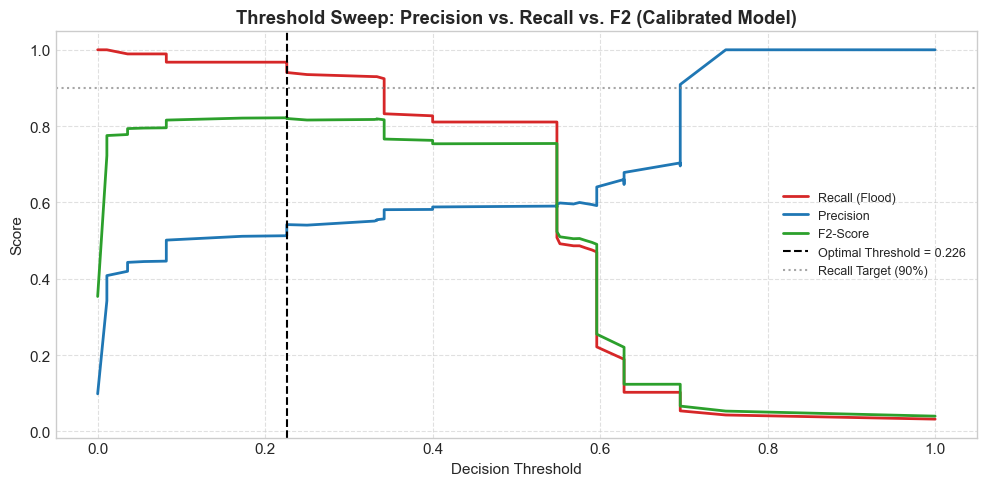

FINAL HELD-OUT TEST REPORT — no model choices are made from this table


,Configuration,Threshold,PR-AUC,ROC-AUC,Recall,Precision,F1,F2,FP,FN,Disaster Cost
0,Fixed baseline @ 0.50,0.500,0.6057,0.9602,0.9353,0.5210,0.6692,0.8070,319,24,559.0
1,Tuned raw model @ 0.50,0.500,0.6174,0.9631,0.8814,0.5860,0.7040,0.8007,231,44,671.0
2,Final calibrated model @ selected threshold,0.226,0.6085,0.9627,0.9650,0.5408,0.6931,0.8341,304,13,434.0


In [169]:
# ============================================================
# 10.4 Threshold Shifting: Enforcing Flood Recall >= 90%
# ============================================================
# Maximize F2 subject to validation recall >=90%; F2 uses beta squared = 4.
# This objective is not direct minimization of FP + 10*FN.
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_thresh, y_thresh_proba_cal
)
precision_arr = precision_arr[:-1]   # align lengths with thresholds
recall_arr    = recall_arr[:-1]

beta = 2.0
f2_arr = (1 + beta**2) * (precision_arr * recall_arr) / \
         ((beta**2 * precision_arr) + recall_arr + 1e-12)

# Constraint: Flood Recall must be >= 90%
RECALL_TARGET = 0.90
valid_idx = np.where(recall_arr >= RECALL_TARGET)[0]
optimal_idx = valid_idx[np.argmax(f2_arr[valid_idx])] if len(valid_idx) > 0 else np.argmax(f2_arr)
OPTIMAL_THRESHOLD = float(thresholds_arr[optimal_idx])

print(f"Target Flood Recall Constraint : >= {RECALL_TARGET:.0%}")
print(f"Selected Optimal Threshold     : {OPTIMAL_THRESHOLD:.4f}")
print(f"Recall    @ optimal threshold  : {recall_arr[optimal_idx]:.4f}")
print(f"Precision @ optimal threshold  : {precision_arr[optimal_idx]:.4f}")
print(f"F2-Score  @ optimal threshold  : {f2_arr[optimal_idx]:.4f}")

# --- Threshold sweep visualization ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_arr, recall_arr,    label='Recall (Flood)', color='#d62728', linewidth=2)
ax.plot(thresholds_arr, precision_arr, label='Precision',      color='#1f77b4', linewidth=2)
ax.plot(thresholds_arr, f2_arr,        label='F2-Score',       color='#2ca02c', linewidth=2)
ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--',
           label=f'Optimal Threshold = {OPTIMAL_THRESHOLD:.3f}')
ax.axhline(RECALL_TARGET, color='gray', linestyle=':', alpha=0.7, label='Recall Target (90%)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sweep: Precision vs. Recall vs. F2 (Calibrated Model)', fontweight='bold')
ax.legend(loc='center right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# All model, calibration, and threshold choices are now fixed.
# First and final evaluation phase on the held-out test partition.
X_test_proc = fitted_preprocessing.transform(X_test)
y_test_proba = final_model.predict_proba(X_test_proc)[:, 1]
y_test_proba_tuned = tuned_model.predict_proba(X_test_proc)[:, 1]
y_test_proba_cal = calibrated_model.predict_proba(X_test_proc)[:, 1]
results = [
    evaluate_configuration(y_test, y_test_proba, 0.5, 'Fixed baseline @ 0.50'),
    evaluate_configuration(y_test, y_test_proba_tuned, 0.5, 'Tuned raw model @ 0.50'),
    evaluate_configuration(y_test, y_test_proba_cal, OPTIMAL_THRESHOLD,
                           'Final calibrated model @ selected threshold')
]
final_report = pd.DataFrame(results)
print('FINAL HELD-OUT TEST REPORT — no model choices are made from this table')
final_report

C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\808436301.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cost_compare, x='Configuration', y='Disaster Cost',
C:\Users\gamit\AppData\Local\Temp\ipykernel_23172\808436301.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=10, ha='right')


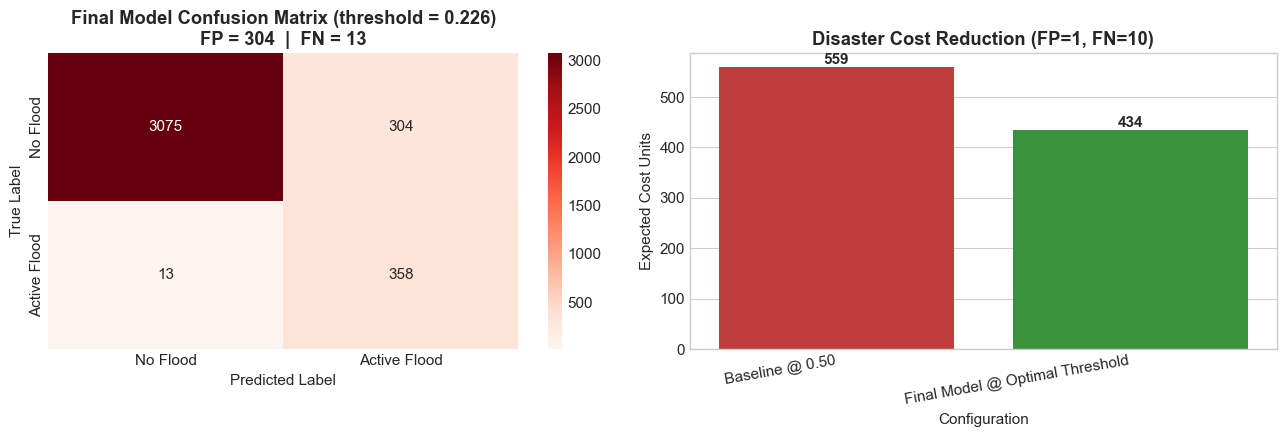


✓ Flood Recall on Test Set  : 96.50%
✓ Disaster Cost Reduction   : 559  →  434 (22.4% reduction)


In [170]:
# ============================================================
# 10.4b Final Model Confusion Matrix & Disaster Cost Reduction
# ============================================================
y_test_pred_final = (y_test_proba_cal >= OPTIMAL_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_test_pred_final)

tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, (y_test_proba >= 0.50).astype(int)).ravel()
cost_baseline = fp_b * FP_COST + fn_b * FN_COST
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()
cost_final = fp_f * FP_COST + fn_f * FN_COST

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['No Flood', 'Active Flood'],
            yticklabels=['No Flood', 'Active Flood'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title(f'Final Model Confusion Matrix (threshold = {OPTIMAL_THRESHOLD:.3f})\n'
                  f'FP = {fp_f}  |  FN = {fn_f}', fontweight='bold')

cost_compare = pd.DataFrame({
    'Configuration': ['Baseline @ 0.50', 'Final Model @ Optimal Threshold'],
    'Disaster Cost': [cost_baseline, cost_final]
})
sns.barplot(data=cost_compare, x='Configuration', y='Disaster Cost',
            palette=['#d62728', '#2ca02c'], ax=axes[1])
axes[1].set_title('Disaster Cost Reduction (FP=1, FN=10)', fontweight='bold')
axes[1].set_ylabel('Expected Cost Units')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=10, ha='right')

plt.tight_layout()
plt.show()

print(f"\n✓ Flood Recall on Test Set  : {recall_score(y_test, y_test_pred_final):.2%}")
print(f"✓ Disaster Cost Reduction   : {cost_baseline:,.0f}  →  {cost_final:,.0f} "
      f"({(1 - cost_final / cost_baseline):.1%} reduction)")

### 10.5 Model Improvement Protocol
Optuna maximizes training CV average precision using fold-local preprocessing. Isotonic calibration uses one validation half; F2 threshold selection uses the other. The test report is generated only after these choices are fixed. The recall constraint applies to the threshold-selection sample, not as a guarantee on unseen data. The objective maximizes F2 subject to recall; it does not directly minimize the illustrative disaster cost.

## Step 11: Deployment & Export — Pipeline Assembly & Metadata Generation
**Assigned Member: Member 4**  
Encapsulates raw data sanitization, physical feature engineering, scaling, isotonic calibration, and validation-selected threshold shifting into a unified `scikit-learn` Pipeline exported to `flood_alert_pipeline.pkl` and `model_metadata.json`.

Measured Pipeline Test Recall: 96.50%
Pipeline Precision:                   54.08%
Pipeline F1-Score:                    0.6931
Total Disaster Cost (FP*1 + FN*10):   434.0
Exported pipeline to: c:\Users\gamit\OneDrive\Documents\MyWork\ML\FloodSentinel\flood_alert_pipeline.pkl
Exported metadata to: c:\Users\gamit\OneDrive\Documents\MyWork\ML\FloodSentinel\model_metadata.json


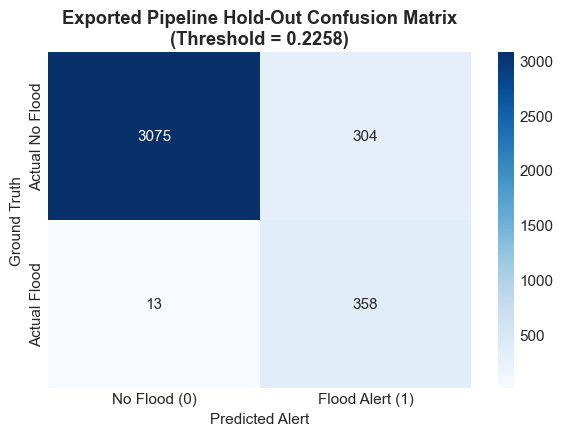

In [171]:
class CalibratedThresholdClassifier(ClassifierMixin, BaseEstimator):
    """Fitted inference wrapper with isotonic calibration and a validation-selected threshold."""
    def __init__(self, base_model=None, calibrator=None, threshold=0.5):
        self.base_model = base_model
        self.calibrator = calibrator
        self.threshold = threshold
        self.classes_ = np.array([0, 1])

    def fit(self, X, y=None):
        raise RuntimeError('Inference-only wrapper: train using Steps 7–10 before export.')

    def predict_proba(self, X):
        raw_proba = self.base_model.predict_proba(X)[:, 1]
        cal_proba = np.clip(self.calibrator.predict(raw_proba), 0.0, 1.0)
        return np.column_stack([1.0 - cal_proba, cal_proba])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)


# Assemble end-to-end pipeline
sanitizer = fitted_preprocessing.named_steps['sanitizer']
preprocessor = fitted_preprocessing.named_steps['preprocessor']

flood_pipeline = Pipeline([
    ('sanitizer', sanitizer),
    ('feature_engineer', fitted_preprocessing.named_steps['feature_engineer']),
    ('preprocessor', preprocessor),
    ('classifier', CalibratedThresholdClassifier(tuned_model, isotonic_calibrator, threshold=OPTIMAL_THRESHOLD))
])

# Evaluate on raw test set (all original 32 columns)
raw_test_df = df.loc[X_test.index]
pipeline_preds = flood_pipeline.predict(raw_test_df)
pipeline_probs = flood_pipeline.predict_proba(raw_test_df)[:, 1]

np.testing.assert_allclose(pipeline_probs, y_test_proba_cal, rtol=1e-7, atol=1e-9)
np.testing.assert_array_equal(pipeline_preds, y_test_pred_final)

p_rec = recall_score(y_test, pipeline_preds)
p_prec = precision_score(y_test, pipeline_preds, zero_division=0)
p_f1 = f1_score(y_test, pipeline_preds, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, pipeline_preds).ravel()
p_cost = fp * FP_COST + fn * FN_COST

print(f"Measured Pipeline Test Recall: {p_rec:.2%}")
print(f"Pipeline Precision:                   {p_prec:.2%}")
print(f"Pipeline F1-Score:                    {p_f1:.4f}")
print(f"Total Disaster Cost (FP*1 + FN*10):   {p_cost:,.1f}")

# Export to flood_alert_pipeline.pkl
pipeline_path = PROJECT_ROOT / "flood_alert_pipeline.pkl"
with pipeline_path.open("wb") as f:
    cloudpickle.dump(flood_pipeline, f)
print(f"Exported pipeline to: {pipeline_path}")

# Generate model_metadata.json with clean operational sample payloads (no ground-truth/leakage fields)
drop_cols_set = set(sanitizer.cols_to_drop)
flood_sample = {k: v for k, v in df[df['flood_occurrence_current_event'] == 'Yes'].iloc[0].to_dict().items() if k not in drop_cols_set}
normal_sample = {k: v for k, v in df[df['flood_occurrence_current_event'] == 'No'].iloc[0].to_dict().items() if k not in drop_cols_set}

metadata = {
    "model_name": "FloodSentinel-EarlyWarning",
    "version": "1.1.0",
    "assigned_member": "Member 4 (Deployment & Export)",
    "architecture": "XGBoost + Isotonic Calibration + Threshold Shifting",
    "decision_threshold": float(OPTIMAL_THRESHOLD),
    "recall_constraint": ">=90% on threshold-selection validation subset; no future guarantee",
    "data_scope": "All 25,000 records are marked synthetic; real-event validation is required",
    "threshold_objective": "Maximize F2 subject to validation recall >=0.90",
    "training_rows": len(X_train),
    "validation_rows": len(X_val),
    "test_rows": len(X_test),
    "random_seed": 42,
    "package_versions": {name: __import__('importlib.metadata', fromlist=['version']).version(name)
                         for name in ['numpy', 'pandas', 'scikit-learn', 'xgboost', 'cloudpickle', 'joblib']},
    "test_metrics": {
        "recall": round(float(p_rec), 4),
        "precision": round(float(p_prec), 4),
        "f1": round(float(p_f1), 4),
        "disaster_cost": float(p_cost)
    },
    "sample_payloads": {
        "high_risk_flood": flood_sample,
        "low_risk_normal": normal_sample
    }
}

metadata_path = PROJECT_ROOT / "model_metadata.json"
with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)
print(f"Exported metadata to: {metadata_path}")

# Visualize Pipeline Confusion Matrix on Hold-Out Test Set
plt.figure(figsize=(6, 4.5))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Flood (0)', 'Flood Alert (1)'],
            yticklabels=['Actual No Flood', 'Actual Flood'])
plt.title(f"Exported Pipeline Hold-Out Confusion Matrix\n(Threshold = {OPTIMAL_THRESHOLD:.4f})", fontweight='bold')
plt.xlabel("Predicted Alert")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()

In [172]:
# ============================================================
# 11.2 Standalone Inference Simulation & Sanity Check
# ============================================================
print("Testing exported pipeline on sample synthetic inputs...\n")
pipe = joblib.load(pipeline_path)

samples = [
    ("Synthetic flood-labelled sample", metadata['sample_payloads']['high_risk_flood']),
    ("Synthetic non-flood-labelled sample", metadata['sample_payloads']['low_risk_normal'])
]

for label, payload in samples:
    prob = float(pipe.predict_proba(payload)[0, 1])
    pred = int(pipe.predict(payload)[0])
    status = "MODEL FLOOD FLAG (DEMONSTRATION)" if pred == 1 else "NO MODEL FLOOD FLAG"
    print(f"{label}:")
    print(f"  District:           {payload.get('district')}")
    print(f"  7-Day Rainfall:     {payload.get('rainfall_7d_mm')} mm")
    print(f"  Calibrated Risk:    {prob:.2%}")
    print(f"  Threshold:          {OPTIMAL_THRESHOLD:.4f}")
    print(f"  Model Output:      {status}\n")

Testing exported pipeline on sample synthetic inputs...

Synthetic flood-labelled sample:
  District:           Trincomalee
  7-Day Rainfall:     255.7 mm
  Calibrated Risk:    59.60%
  Threshold:          0.2258
  Model Output:      MODEL FLOOD FLAG (DEMONSTRATION)

Synthetic non-flood-labelled sample:
  District:           Kegalle
  7-Day Rainfall:     140.8 mm
  Calibrated Risk:    0.00%
  Threshold:          0.2258
  Model Output:      NO MODEL FLOOD FLAG



### 11.3 Export Verification and Limits
The exported pipeline reuses the fitted training transformations and reproduces the final test probabilities and labels exactly (asserted above). Reloaded sample inference is demonstrated without redefining the pipeline. Metadata records the full-precision threshold and dependency versions.

All 25,000 records are marked synthetic. This notebook is a reproducible classification experiment for current-event flood occurrence, not evidence of advance warning performance. A random split does not measure generalization across future storms or unseen regions. Real observations with timestamps, verified input availability before the forecast horizon, and spatial/temporal evaluation are required before operational use. The model returns a probability and binary flag; four alert tiers are not implemented. Missing categorical fields other than electricity are required inputs.